In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [7]:
import os

# Find the correct path
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if 'metadata' in file.lower():
            print(os.path.join(root, file))

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


In [8]:
from fastai.vision.all import *
import pandas as pd
from pathlib import Path
from torch import tensor
import os

# Setup paths
path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
df = pd.read_csv(f'{path}/HAM10000_metadata.csv')

part1 = f'{path}/HAM10000_images_part_1'
part2 = f'{path}/HAM10000_images_part_2'

# Connect images to labels
def get_image_path(image_id):
    for folder in [part1, part2]:
        p = Path(folder)/f'{image_id}.jpg'
        if p.exists(): return p

df['path'] = df['image_id'].map(get_image_path)

# Build DataBlock - NO aug_transforms this time
# aug_transforms only for training, not for export
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('path'),
    get_y=ColReader('dx'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=2.0)
).dataloaders(df, bs=32)

# Fix class imbalance
counts = df['dx'].value_counts()
weights = [1.0/counts[c] for c in dls.vocab]
class_weights = tensor(weights).float().cuda()

# Train
learn = vision_learner(
    dls,
    resnet50,
    metrics=[accuracy, RocAuc()],
    loss_func=CrossEntropyLossFlat(weight=class_weights)
)

learn.fine_tune(8, freeze_epochs=3)

# THIS IS THE KEY FIX
# Remove augmentation transforms before exporting
# So the saved model has clean simple pipeline
learn.dls = learn.dls.new(
    item_tfms=Resize(224),
    batch_tfms=[Normalize.from_stats(*imagenet_stats)]
)

learn.export('skin_model.pkl')
print('Saved! Size:', os.path.getsize('skin_model.pkl'))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]


epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,2.286005,1.538034,0.432851,0.836504,01:12
1,1.902813,1.471996,0.440839,0.852734,01:13
2,1.621662,1.278125,0.507738,0.875762,01:12


epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,1.264526,1.019147,0.600100,0.914630,01:36
1,1.135483,0.874963,0.681977,0.933369,01:36
2,0.961967,0.803998,0.669496,0.941667,01:36
3,0.830463,0.749856,0.712431,0.948913,01:36
4,0.697642,0.739937,0.726410,0.949995,01:36
5,0.639946,0.742934,0.750874,0.957005,01:36
6,0.549188,0.703412,0.747379,0.959009,01:36
7,0.511748,0.708416,0.760859,0.960781,01:36


Saved! Size: 103209055


In [10]:
from IPython.display import FileLink
FileLink('skin_model.pkl')

/kaggle/working/skin_model.pkl

In [14]:
from fastai.vision.all import *
import pandas as pd
from pathlib import Path
from torch import tensor
import os

# Setup
path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
df = pd.read_csv(f'{path}/HAM10000_metadata.csv')

part1 = f'{path}/HAM10000_images_part_1'
part2 = f'{path}/HAM10000_images_part_2'

def get_image_path(image_id):
    for folder in [part1, part2]:
        p = Path(folder)/f'{image_id}.jpg'
        if p.exists(): return p

df['path'] = df['image_id'].map(get_image_path)

# DataBlock
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('path'),
    get_y=ColReader('dx'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=2.0)
).dataloaders(df, bs=32)

# Class weights
counts = df['dx'].value_counts()
weights = [1.0/counts[c] for c in dls.vocab]
class_weights = tensor(weights).float().cuda()

# Train
learn = vision_learner(
    dls,
    resnet50,
    metrics=[accuracy, RocAuc()],
    loss_func=CrossEntropyLossFlat(weight=class_weights)
)

learn.fine_tune(8, freeze_epochs=3)
print("Training done!")

epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,2.302057,1.640538,0.403894,0.825955,01:13
1,2.013532,1.463261,0.491263,0.849150,01:12
2,1.779195,1.268279,0.562157,0.875441,01:13


epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,1.317800,1.000912,0.620569,0.915856,01:36
1,1.105118,0.895787,0.616076,0.928419,01:36
2,1.073165,0.918133,0.691962,0.933699,01:36
3,0.842246,0.815699,0.748877,0.950622,01:36
4,0.717007,0.770334,0.754868,0.955030,01:36
5,0.612270,0.762770,0.770844,0.957989,01:36
6,0.518348,0.760240,0.762856,0.959314,01:36
7,0.510306,0.662661,0.773839,0.962876,01:36


Training done!


In [15]:
interp = ClassificationInterpretation.from_learner(learn)
interp.print_classification_report()

              precision    recall  f1-score   support

       akiec       0.60      0.48      0.53        61
         bcc       0.70      0.81      0.75        90
         bkl       0.55      0.78      0.65       241
          df       0.46      0.87      0.60        30
         mel       0.49      0.71      0.58       233
          nv       0.97      0.79      0.87      1316
        vasc       0.72      0.97      0.83        32

    accuracy                           0.77      2003
   macro avg       0.64      0.77      0.69      2003
weighted avg       0.83      0.77      0.79      2003



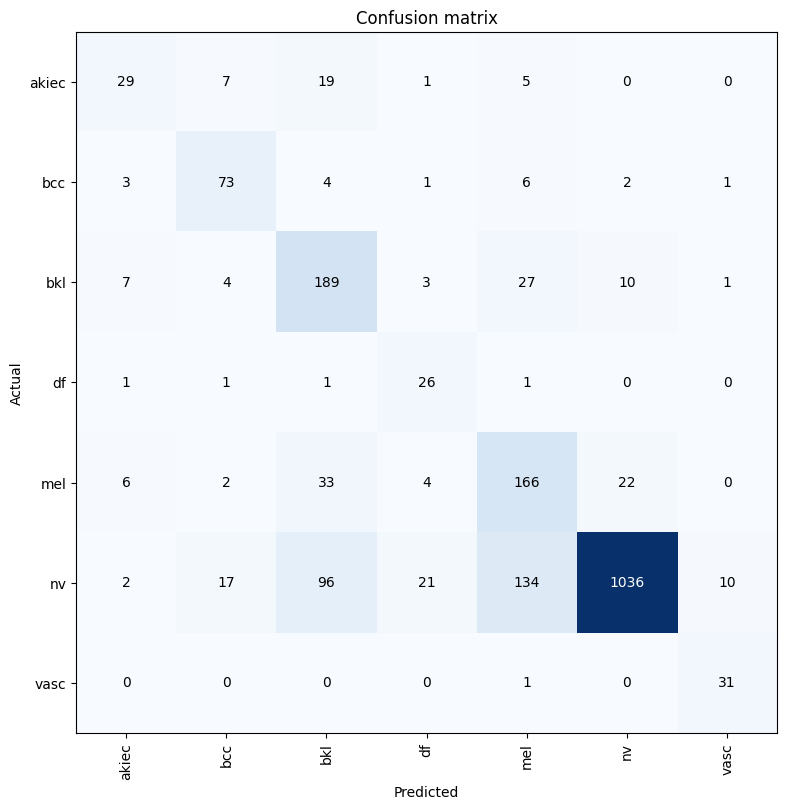

In [16]:
interp.plot_confusion_matrix(figsize=(8,8))

In [17]:
learn.export('skin_model.pkl')
print('Saved! Size:', os.path.getsize('skin_model.pkl'))

Saved! Size: 103262950


In [18]:
from IPython.display import FileLink
FileLink('skin_model.pkl')


/kaggle/working/skin_model.pkl